In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as skm

try:
    import catboost as cb
except:
    ! pip install catboost

### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
int_n_constants = 1000

Project: 20231010-gen-xii
Task: ad_hoc


### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Load in data

In [5]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}_raw.gzip'
    str_uri = f's3://{str_project}/03_pricing_lgd/01_data_prep/03_train_valid_test_split/{str_filename}'
    df = pd.read_parquet(str_uri)
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)
list_cols = [
    'decision_dte__base',
    'open_dte__base',
    'acct_typ_cde__base',
    'terms_freq_cde__base',
    'dtmstampcreation__base',
    'dtmapproved__base',
    'dtmdeclined__base',
    'observationdate__base',
    'analyticsmatchkey__base',
    'booked__base',
    'curr_bal_amt__base',
    'affil_rem_cde__base',
    'cmplnc_rem_cde__base',
    'gnrc_rem_cde__base',
    'rte_rem_cde__base',
    'acct_rte_prfl_cde__base',
    'payt_pttrn_txt__base',
    'gnrcrem_frsrpt_dte__base',
    'obs_arch__base',
    'vtg4__base',
    'performance__base',
    'creditasofdate__tu',
    'credit_as_of_date__tu',
    'strname__tu',
    'state__tu',
]
df.drop(list_cols, axis=1, inplace=True)
# show
df

100%|██████████| 3/3 [00:02<00:00,  1.41it/s]


,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,target,data_set
8202,NaN,NaN,NaN,NaN,REYNOLDSBURG,NaN,NaN,NaN,NaN,NaN,...,398.83,0.229354,0.052130,1,1.106635,auto,0,2012-06-18 09:31:54.393,-0.097929,train
8203,NaN,NaN,NaN,NaN,REYNOLDSBURG,NaN,NaN,NaN,NaN,NaN,...,398.83,0.229354,0.052130,1,1.106635,auto,0,2012-06-18 09:31:54.393,-0.097929,train
8204,NaN,NaN,NaN,NaN,ENGLEWOOD,NaN,NaN,NaN,NaN,NaN,...,420.66,0.470570,0.153369,1,1.254334,auto,1,2012-03-06 16:36:21.623,0.464463,train
8205,NaN,NaN,NaN,NaN,ENGLEWOOD,NaN,NaN,NaN,NaN,NaN,...,420.66,0.470570,0.153369,1,1.254334,auto,1,2012-03-06 16:36:21.623,0.464463,train
8206,NaN,NaN,NaN,NaN,RICHARDSON,NaN,NaN,NaN,NaN,NaN,...,440.04,0.405641,0.050115,0,1.249982,auto,0,2009-10-15 16:06:40.767,0.543609,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,NaN,NaN,NaN,NaN,None,19151.0,NaN,NaN,NaN,20191025.0,...,471.42,0.319547,0.119549,0,1.144597,auto,0,2016-11-11 10:56:15.140,0.175335,test
2335,NaN,NaN,NaN,NaN,None,72112.0,NaN,NaN,NaN,20191025.0,...,592.62,0.493973,0.119966,0,1.333843,auto,0,2003-07-08 14:32:29.097,0.317968,test
5274,NaN,NaN,NaN,NaN,None,77050.0,NaN,NaN,NaN,20191026.0,...,407.00,0.424233,0.117298,0,1.136382,auto,0,2013-09-10 16:40:45.693,0.278606,test
6464,NaN,NaN,NaN,NaN,None,21798.0,NaN,NaN,NaN,20191026.0,...,400.83,0.320787,0.120292,1,1.076209,auto,1,2010-11-12 15:52:36.113,0.660134,test


### Preprocess

In [6]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
# rm
os.remove(str_local_path)

# preprocess
list_target = list(df['target'])
list_cols = [col for col in df.columns if col != 'target']
df = cls_model_preprocessing.transform(df[list_cols])
df['target'] =  list_target

# rm
os.remove('./preprocessing.py')

# show
df

100%|██████████| 2/2 [00:00<00:00,  3.76it/s]


NaN Replacer: 1.3873 sec.


100%|██████████| 3/3 [00:00<00:00, 78.30it/s]

Set strings: 0.040199 sec.


Boolean Replacer: 1.6169 sec.


...


100%|██████████| 2457/2457 [00:02<00:00, 1110.13it/s]


Replace inf and -inf with NaN: 2.6699 sec.
Imputer: 1.1802 sec.
Map term: 0.029618 sec.
Map PTI: 0.03247 sec.


100%|██████████| 9/9 [00:00<00:00, 1318.18it/s]

Round values: 0.010402 sec.
Preprocessing Model: 13.987 sec.


,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target
8202,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929
8203,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929
8204,0.0,0.0,0.0,0.0,englewood,0.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463
8205,0.0,0.0,0.0,0.0,englewood,0.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463
8206,0.0,0.0,0.0,0.0,richardson,0.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,0.0,0.0,0.0,0.0,nan,19151.0,0.0,0.0,0.0,20191025.0,...,test,2019,1.144717,10,4,0.09,1.236842,1.0,2.953425,0.175335
2335,0.0,0.0,0.0,0.0,nan,72112.0,0.0,0.0,0.0,20191025.0,...,test,2019,1.144717,10,4,0.12,1.500000,3.0,16.306849,0.317968
5274,0.0,0.0,0.0,0.0,nan,77050.0,0.0,0.0,0.0,20191026.0,...,test,2019,1.144717,10,4,0.09,1.290323,3.0,6.126027,0.278606
6464,0.0,0.0,0.0,0.0,nan,21798.0,0.0,0.0,0.0,20191026.0,...,test,2019,1.144717,10,4,0.09,1.233333,3.0,8.956164,0.660134


### Subset to noBK

In [7]:
df.intopenbktype__app.value_counts()

intopenbktype__app
nan     37097
7.0     13398
13.0     6448
Name: count, dtype: int64

In [8]:
df = df[df['intopenbktype__app'] == 'nan']
df.shape

(37097, 2475)

### Get LGD predictions

In [9]:
# get gen 12 LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['yhat'] = cls_model_inference.predict(df[list_cols_model])
# show
df

,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target,yhat
8202,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929,0.435195
8203,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929,0.419317
8206,0.0,0.0,0.0,0.0,richardson,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609,0.485704
8207,0.0,0.0,0.0,0.0,richardson,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609,0.471772
8208,0.0,0.0,0.0,0.0,silvercreek,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.12,1.588235,2.0,0.838356,0.654268,0.360220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,0.0,0.0,0.0,0.0,nan,19151.0,0.0,0.0,0.0,20191025.0,...,2019,1.144717,10,4,0.09,1.236842,1.0,2.953425,0.175335,0.454106
2335,0.0,0.0,0.0,0.0,nan,72112.0,0.0,0.0,0.0,20191025.0,...,2019,1.144717,10,4,0.12,1.500000,3.0,16.306849,0.317968,0.489100
5274,0.0,0.0,0.0,0.0,nan,77050.0,0.0,0.0,0.0,20191026.0,...,2019,1.144717,10,4,0.09,1.290323,3.0,6.126027,0.278606,0.452178
6464,0.0,0.0,0.0,0.0,nan,21798.0,0.0,0.0,0.0,20191026.0,...,2019,1.144717,10,4,0.09,1.233333,3.0,8.956164,0.660134,0.463597


### Get RMSE by data set

In [10]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_dict_row = []
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # get rmse
    flt_score = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat'],
    ))
    dict_row = {
        'df': str_df,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_model_score = pd.DataFrame(list_dict_row)
df_model_score

100%|██████████| 3/3 [00:01<00:00,  2.25it/s]


,df,score
0,train,0.243935
1,valid,0.274657
2,test,0.273273


### Constants

In [11]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_flt_constant = list(np.linspace(0, 1.0, int_n_constants))
list_dict_row = []
for flt_constant in tqdm(list_flt_constant):
    # create tmp constant pred
    df['yhat_constant'] = flt_constant
    
    # train
    df_tmp = df[df['data_set'] == 'train'].copy()
    # get rmse
    flt_score_train = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat_constant'],
    ))
    
    # valid
    df_tmp = df[df['data_set'] == 'valid'].copy()
    # get rmse
    flt_score_valid = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat_constant'],
    ))
    
    # test
    df_tmp = df[df['data_set'] == 'test'].copy()
    # get rmse
    flt_score_test = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat_constant'],
    ))
    
    # row
    dict_row = {
        'constant': flt_constant,
        'score_train': flt_score_train,
        'score_valid': flt_score_valid,
        'score_test': flt_score_test,
    }
    list_dict_row.append(dict_row)
df_constant_score = pd.DataFrame(list_dict_row)
df_constant_score

100%|██████████| 1000/1000 [22:21<00:00,  1.34s/it]


,constant,score_train,score_valid,score_test
0,0.000000,0.519531,0.534044,0.554472
1,0.001001,0.518678,0.533202,0.553609
2,0.002002,0.517826,0.532361,0.552746
3,0.003003,0.516974,0.531520,0.551883
4,0.004004,0.516122,0.530679,0.551021
...,...,...,...,...
995,0.995996,0.616156,0.618066,0.588436
996,0.996997,0.617055,0.618952,0.589317
997,0.997998,0.617954,0.619838,0.590198
998,0.998999,0.618853,0.620724,0.591079


### Plot

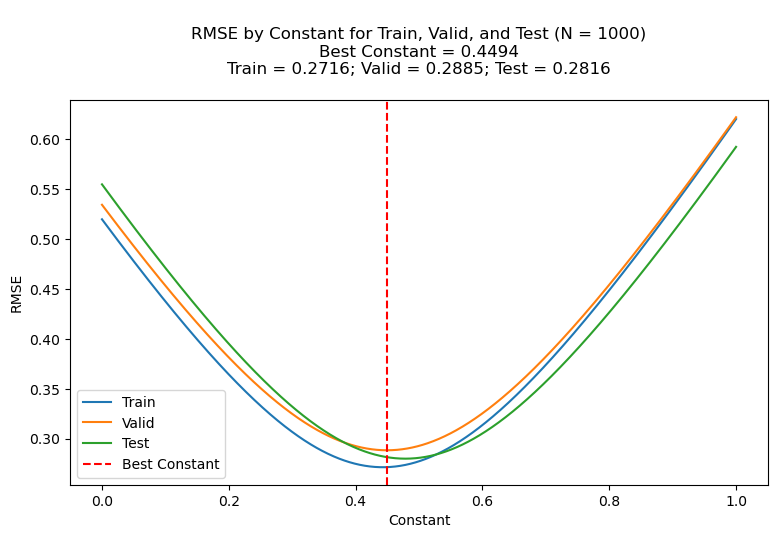

In [12]:
df_tmp = df_constant_score.sort_values(by='score_valid', ascending=True, inplace=False)
flt_constant = df_tmp['constant'].iloc[0]
flt_train = df_tmp['score_train'].iloc[0]
flt_valid = df_tmp['score_valid'].iloc[0]
flt_test = df_tmp['score_test'].iloc[0]
str_title = f"""
RMSE by Constant for Train, Valid, and Test (N = {int_n_constants})
Best Constant = {flt_constant:0.4f}
Train = {flt_train:0.4f}; Valid = {flt_valid:0.4f}; Test = {flt_test:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Constant')
ax.set_ylabel('RMSE')
# train
ax.plot(df_constant_score['constant'], df_constant_score['score_train'], label='Train')
# valid
ax.plot(df_constant_score['constant'], df_constant_score['score_valid'], label='Valid')
# test
ax.plot(df_constant_score['constant'], df_constant_score['score_test'], label='Test')
# vertical line
ax.axvline(flt_constant, linestyle='--', color='red', label='Best Constant')
# legend
plt.legend()
# show
plt.show()